In [ ]:
                # -------Random Imputation------#
# Fill the missing value using random value instead of mean, median, mode.

# Advantages:
    # Easy to use
    # Preserve orginal variance
    # Distribution remain same
    # Fit for linear and logistic regression
# Disadvantages:
    # Not fit for Decesion tree
    # Required heavy memory server


In [6]:
# Rnadom Imputation on Numerical Value
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

In [2]:
# Import required dataset
Data=pd.read_csv('titanic_toy.csv', usecols=['Age', 'Fare', 'Survived'])

In [3]:
# Check any null value
Data.isnull().mean()*100

Age         19.865320
Fare         5.050505
Survived     0.000000
dtype: float64

In [4]:
# Split train and test set
X=Data.drop(columns='Survived')
y=Data['Survived']

In [ ]:
# Split the data
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, 
    random_state=2)

In [7]:
# Create ne column name age_imputed
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [8]:

# Perform Imputation
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

C:\Users\Kamely\AppData\Local\Temp\ipykernel_14284\2878462536.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values


In [9]:
# Check X_train
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([19. , 27. , 26. , 45. , 34. ,  9. , 23. , 23. , 40. , 19. , 25. ,
       18. , 18. , 42. , 60. , 57. , 36. , 22. , 38. , 16. , 32. , 14.5,
       32. , 24. ,  4. , 16. , 51. , 51. , 21. , 32. , 27. , 37. , 36. ,
       62. , 36. , 47. , 34. , 18. , 39. , 17. , 36. , 41. , 10. , 15. ,
       13. , 54. , 39. , 36. , 33. , 56. , 16. , 35. , 28. , 17. , 22. ,
       30. , 21. , 22. , 31. , 20. , 20. , 16. , 29. ,  5. , 48. , 30. ,
       52. , 58. , 22. , 45.5, 32. , 38. , 14. , 25. , 28. , 45. , 22. ,
       35. , 50. ,  1. , 23. , 46. , 34. , 48. ,  4. ,  5. , 52. , 24. ,
       30. ,  7. ,  4. , 28.5, 40. , 25. , 23. , 24. , 39. ,  6. , 18. ,
       31. , 36. , 35. , 29. , 30. , 35. , 19. , 26. , 39. , 29. , 28. ,
       38. , 44. , 32. , 11. , 58. , 19. , 42. , 28. , 42. , 20. , 36. ,
       16. ,  9. , 27. , 20. , 22. , 45. , 44. , 29. , 26. ,  9. , 35. ,
       19. , 29. , 62. , 37. , 12. , 27. , 33. , 24. , 47. , 24. , 35. ,
       28. , 26. , 16. , 19. , 16. ])

In [11]:
X_train.head(10)

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
213,30.0,13.0000,30.0
157,30.0,8.0500,30.0
780,13.0,7.2292,13.0
572,36.0,26.3875,36.0
77,NaN,8.0500,28.0


C:\Users\Kamely\AppData\Local\Temp\ipykernel_14284\3148918748.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
C:\Users\Kamely\AppData\Local\Temp\ipykernel_14284\3148918748.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_trai

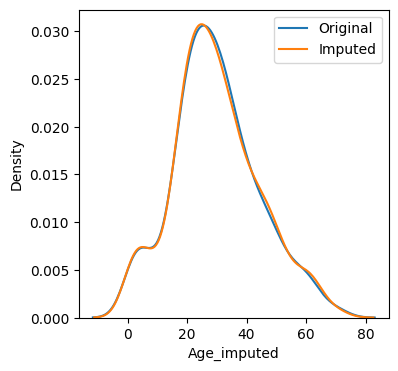

In [13]:
# Draw distribution plot
plt.figure(figsize=(4,4))
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [14]:
# Check Variance
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  208.31376427230995


In [15]:
# Check covariance
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2448.197914,70.719262,42.711923
Age,70.719262,204.349513,204.349513
Age_imputed,42.711923,204.349513,208.313764


<Axes: >

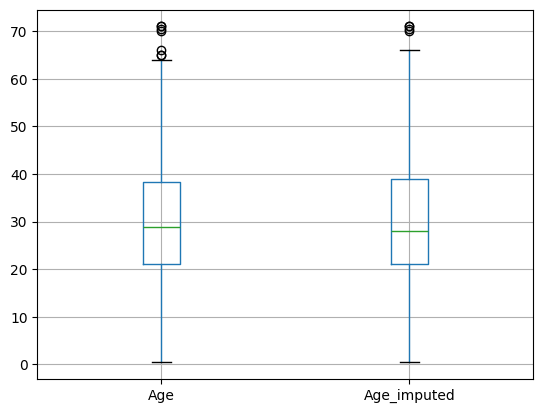

In [16]:
# Check outlier
X_train[['Age', 'Age_imputed']].boxplot()

In [19]:
# Sample value remain same using random state when use in production phase
age_non_missing = X_train['Age'].dropna()

missing_index = X_train[X_train['Age'].isnull()].index

random_sample = age_non_missing.sample(
    len(missing_index),
    replace=True,
    random_state=42
)

X_train.loc[missing_index, 'Age'] = random_sample.values